# Linear Regression using Scikit-Learn

## Goals
Use scikit-learn's built-in gradient descent regressor instead of implementing everything by hand.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor    #gradient descent for regression
from sklearn.preprocessing import StandardScaler  #scaler for normlization   #preporcessing for prepaering data before feeding to model
np.set_printoptions(precision=2)

### Load and scale the data
We'll reuse the same house dataset from the feature scaling lab.

In [3]:
np.random.seed(1)
m = 100
size = np.random.randint(800, 2500, m)
bedrooms = np.random.randint(1, 5, m)
floors = np.random.randint(1, 3, m)
age = np.random.randint(1, 80, m)

X_train = np.column_stack((size, bedrooms, floors, age))
y_train = (size * 0.2 + bedrooms * 15 - age * 1.5 + np.random.randn(m) * 20 + 50)
X_features = ['size(sqft)', 'bedrooms', 'floors', 'age']

### Scale the training data

In [6]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)   #fir for men and std and transform for formulla of z_score norm, so collectively working fit_transform
print(f"Peak to Peak range by column in Raw X: {np.ptp(X_train, axis=0)}")
print(f"Peak to Peak range by column in Normalized X: {np.ptp(X_norm, axis=0)}")

Peak to Peak range by column in Raw X: [1674    3    1   78]
Peak to Peak range by column in Normalized X: [3.6  2.75 2.01 3.62]


### Create and fit the regression model

In [10]:
sgdr = SGDRegressor(max_iter=1000)  #max_iters mean max loops  #no alpha , it automatically detect
sgdr.fit(X_norm,y_train)
print(sgdr)      # n_iters = ow many iterations it actually took to converge  # t_ = total number of individual weight updates performed
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

SGDRegressor()
number of iterations completed: 74, number of weight updates: 7401.0


### View parameters
The learned parameters are associated with the normalized input data.

In [12]:
b_norm = sgdr.intercept_  #interrcept of regression =b
w_norm = sgdr.coef_       #coeficient of resgression =w
print(f"model parameters: w: {w_norm}, b:{b_norm}")

model parameters: w: [ 90.92  15.33  -3.14 -31.  ], b:[371.43]


### Make predictions
Compare predictions using sgdr.predict() against manually computing with np.dot() and the extracted w, b.

In [13]:
y_pred_sgd = sgdr.predict(X_norm)
y_pred = np.dot(X_norm, w_norm) + b_norm
print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

print(f"Prediction on training set:\n{y_pred[:4]}")
print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[393.71 191.6  391.09 398.84]
Target values 
[396.07 175.97 418.33 395.75]


### Plot Results
Predictions versus target values, across each original feature.

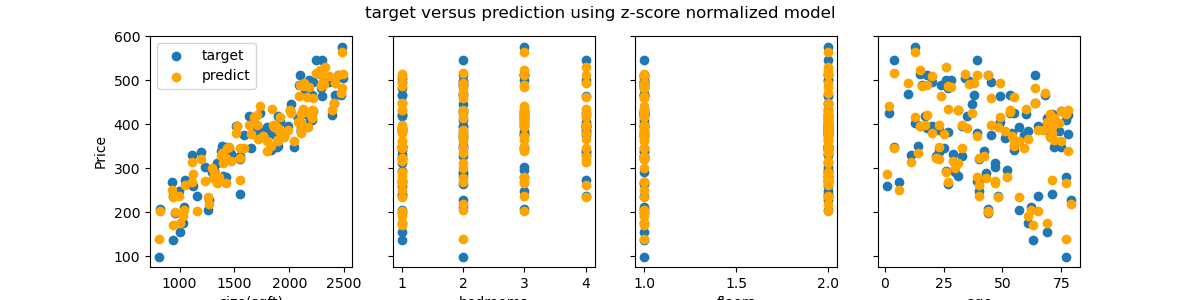

In [14]:
fig, ax = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:, i], y_train, label='target')
    ax[i].scatter(X_train[:, i], y_pred, color='orange', label='predict')
    ax[i].set_xlabel(X_features[i])
ax[0].set_ylabel("Price")
ax[0].legend()
fig.suptitle("target versus prediction using z-score normalized model")
plt.savefig("sklearn_predictions.png")
plt.close()

from IPython.display import Image
Image("sklearn_predictions.png")

## Summary

Used scikit-learn to replicate everything built by hand in previous labs — normalization, gradient descent, and prediction — confirming the manual implementation matches a production-grade library's results.

### Scikit-learn functions used

- **`StandardScaler()`** — creates a scaler object for z-score normalization (same math as the hand-built `zscore_normalize_features`: subtract the mean, divide by standard deviation).
- **`scaler.fit_transform(X_train)`** — calculates the mean/std from the training data AND applies the normalization in one step.
- **`SGDRegressor(max_iter=1000)`** — creates a gradient descent regression model. Handles weight initialization, learning rate, and convergence automatically, unlike the fixed-alpha version built by hand.
- **`sgdr.fit(X_norm, y_train)`** — trains the model; this is where gradient descent actually runs internally.
- **`sgdr.predict(X_norm)`** — generates predictions using the model's learned weights, only usable after `.fit()` has been called.
- **`sgdr.coef_`** — the learned weight vector (equivalent to `w` in the hand-built version).
- **`sgdr.intercept_`** — the learned